Dataset Shape: (545, 13)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no  

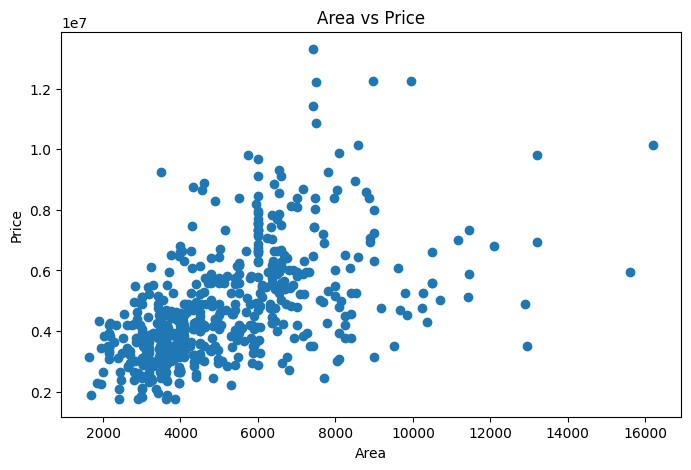


Polynomial Regression Results
 Degree  Training MSE  Testing MSE  Training RMSE  Testing RMSE  Training R2  Testing R2
      1  2.204739e+12 3.675287e+12   1.484836e+06  1.917104e+06     0.284963    0.272879
      3  2.063400e+12 3.563793e+12   1.436454e+06  1.887801e+06     0.330802    0.294936
     10  2.714219e+12 4.649121e+12   1.647489e+06  2.156182e+06     0.119730    0.080214


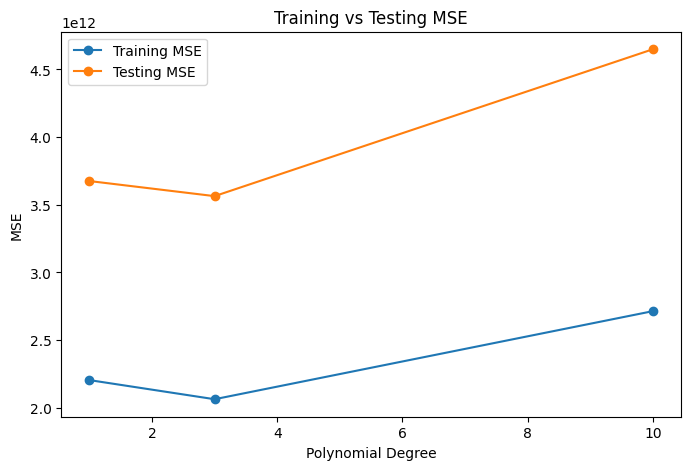

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


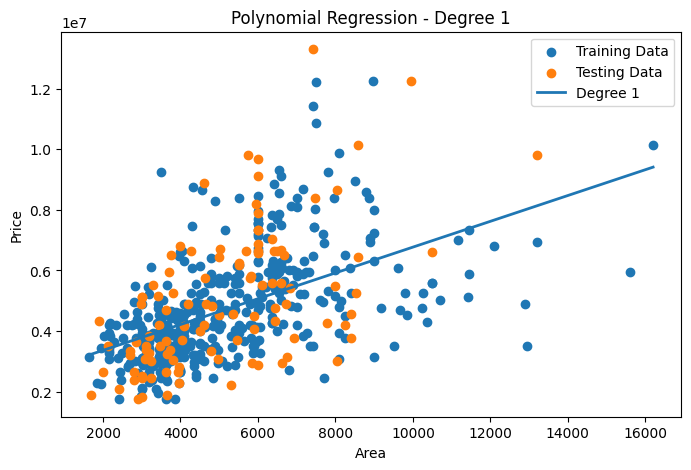

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


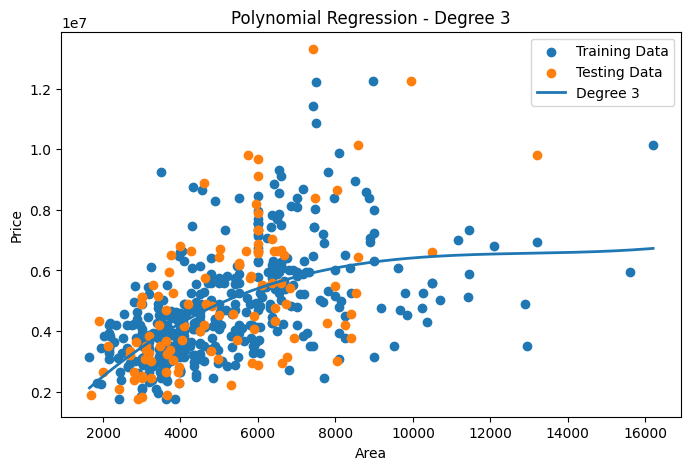

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


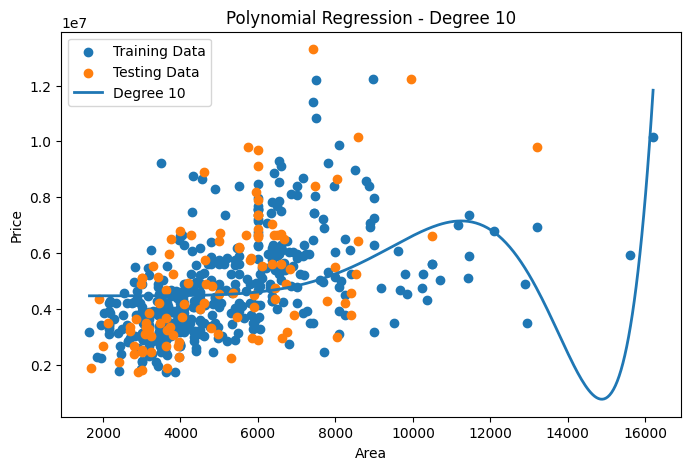


Degree 10 Model
Training MSE: 2714219043718.0513
Testing MSE: 4649120990903.739
Training R2: 0.1197295993402725
Testing R2: 0.08021438731571595

Ridge Regression Results
 Alpha  Training MSE  Testing MSE  Training R2  Testing R2
  0.01  1.943416e+12 3.724532e+12     0.369715    0.263136
  0.10  1.956538e+12 3.726766e+12     0.365459    0.262694
  1.00  1.971298e+12 3.716714e+12     0.360672    0.264682
 10.00  1.990361e+12 3.675904e+12     0.354490    0.272756
100.00  2.175473e+12 3.784662e+12     0.294455    0.251240

Best Ridge Alpha: 10.0


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.219e+14, tolerance: 1.344e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.207e+14, tolerance: 1.344e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.094e+14, tolerance: 1.344e


Lasso Regression Results
 Alpha  Training MSE  Testing MSE  Training R2  Testing R2
  0.01  1.935850e+12 3.715430e+12     0.372169    0.264937
  0.10  1.935855e+12 3.715439e+12     0.372167    0.264935
  1.00  1.935902e+12 3.715530e+12     0.372152    0.264917
 10.00  1.936401e+12 3.716463e+12     0.371990    0.264732
100.00  1.941718e+12 3.723861e+12     0.370266    0.263268

Best Lasso Alpha: 0.01

Ridge Coefficients
Feature   Coefficient  Absolute Coefficient
      1  0.000000e+00          0.000000e+00
   area  1.251604e+06          1.251604e+06
 area^2  4.527475e+05          4.527475e+05
 area^3 -2.707183e+05          2.707183e+05
 area^4 -5.786380e+05          5.786380e+05
 area^5 -5.309463e+05          5.309463e+05
 area^6 -3.146822e+05          3.146822e+05
 area^7 -6.197243e+04          6.197243e+04
 area^8  1.678877e+05          1.678877e+05
 area^9  3.584906e+05          3.584906e+05
area^10  5.117098e+05          5.117098e+05

Lasso Coefficients
Feature   Coefficient
      

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.424e+11, tolerance: 1.344e+11
  model = cd_fast.enet_coordinate_descent(


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("/content/Housing.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

X = df[["area"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

degrees = [1, 3, 10]
polynomial_results = []
polynomial_models = {}

for degree in degrees:

    model = Pipeline([
        ("polynomial", PolynomialFeatures(degree=degree)),
        ("regression", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    polynomial_models[degree] = model

    polynomial_results.append([
        degree,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_r2,
        test_r2
    ])

polynomial_results_df = pd.DataFrame(
    polynomial_results,
    columns=[
        "Degree",
        "Training MSE",
        "Testing MSE",
        "Training RMSE",
        "Testing RMSE",
        "Training R2",
        "Testing R2"
    ]
)

print("\nPolynomial Regression Results")
print(polynomial_results_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(
    polynomial_results_df["Degree"],
    polynomial_results_df["Training MSE"],
    marker="o",
    label="Training MSE"
)
plt.plot(
    polynomial_results_df["Degree"],
    polynomial_results_df["Testing MSE"],
    marker="o",
    label="Testing MSE"
)
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Testing MSE")
plt.legend()
plt.show()

x_range = np.linspace(
    X["area"].min(),
    X["area"].max(),
    300
).reshape(-1, 1)

for degree in degrees:

    model = polynomial_models[degree]
    y_range = model.predict(x_range)

    plt.figure(figsize=(8, 5))
    plt.scatter(X_train, y_train, label="Training Data")
    plt.scatter(X_test, y_test, label="Testing Data")
    plt.plot(
        x_range,
        y_range,
        linewidth=2,
        label=f"Degree {degree}"
    )

    plt.xlabel("Area")
    plt.ylabel("Price")
    plt.title(f"Polynomial Regression - Degree {degree}")
    plt.legend()
    plt.show()

degree_10_model = polynomial_models[10]

degree_10_train_pred = degree_10_model.predict(X_train)
degree_10_test_pred = degree_10_model.predict(X_test)

print("\nDegree 10 Model")
print("Training MSE:", mean_squared_error(y_train, degree_10_train_pred))
print("Testing MSE:", mean_squared_error(y_test, degree_10_test_pred))
print("Training R2:", r2_score(y_train, degree_10_train_pred))
print("Testing R2:", r2_score(y_test, degree_10_test_pred))

alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []
ridge_models = {}

for alpha in alphas:

    model = Pipeline([
        ("polynomial", PolynomialFeatures(degree=10)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    ridge_models[alpha] = model

    ridge_results.append([
        alpha,
        train_mse,
        test_mse,
        train_r2,
        test_r2
    ])

ridge_results_df = pd.DataFrame(
    ridge_results,
    columns=[
        "Alpha",
        "Training MSE",
        "Testing MSE",
        "Training R2",
        "Testing R2"
    ]
)

print("\nRidge Regression Results")
print(ridge_results_df.to_string(index=False))

best_ridge_alpha = ridge_results_df.loc[
    ridge_results_df["Testing MSE"].idxmin(),
    "Alpha"
]

best_ridge_model = ridge_models[best_ridge_alpha]

print("\nBest Ridge Alpha:", best_ridge_alpha)

lasso_results = []
lasso_models = {}

for alpha in alphas:

    model = Pipeline([
        ("polynomial", PolynomialFeatures(degree=10)),
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=100000))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    lasso_models[alpha] = model

    lasso_results.append([
        alpha,
        train_mse,
        test_mse,
        train_r2,
        test_r2
    ])

lasso_results_df = pd.DataFrame(
    lasso_results,
    columns=[
        "Alpha",
        "Training MSE",
        "Testing MSE",
        "Training R2",
        "Testing R2"
    ]
)

print("\nLasso Regression Results")
print(lasso_results_df.to_string(index=False))

best_lasso_alpha = lasso_results_df.loc[
    lasso_results_df["Testing MSE"].idxmin(),
    "Alpha"
]

best_lasso_model = lasso_models[best_lasso_alpha]

print("\nBest Lasso Alpha:", best_lasso_alpha)

ridge_model_step = best_ridge_model.named_steps["ridge"]
ridge_coefficients = ridge_model_step.coef_

ridge_features = best_ridge_model.named_steps[
    "polynomial"
].get_feature_names_out(["area"])

ridge_coefficients_df = pd.DataFrame({
    "Feature": ridge_features,
    "Coefficient": ridge_coefficients,
    "Absolute Coefficient": np.abs(ridge_coefficients)
})

print("\nRidge Coefficients")
print(ridge_coefficients_df.to_string(index=False))

lasso_model_step = best_lasso_model.named_steps["lasso"]
lasso_coefficients = lasso_model_step.coef_

lasso_features = best_lasso_model.named_steps[
    "polynomial"
].get_feature_names_out(["area"])

lasso_coefficients_df = pd.DataFrame({
    "Feature": lasso_features,
    "Coefficient": lasso_coefficients
})

zero_coefficients = np.sum(
    np.isclose(lasso_coefficients, 0)
)

print("\nLasso Coefficients")
print(lasso_coefficients_df.to_string(index=False))

print("\nTotal Lasso Coefficients:", len(lasso_coefficients))
print("Zero Coefficients:", zero_coefficients)

original_test_mse = mean_squared_error(
    y_test,
    degree_10_model.predict(X_test)
)

ridge_test_mse = mean_squared_error(
    y_test,
    best_ridge_model.predict(X_test)
)

lasso_test_mse = mean_squared_error(
    y_test,
    best_lasso_model.predict(X_test)
)

final_comparison = pd.DataFrame({
    "Model": [
        "Polynomial Degree 10",
        f"Ridge Degree 10 (alpha={best_ridge_alpha})",
        f"Lasso Degree 10 (alpha={best_lasso_alpha})"
    ],
    "Test MSE": [
        original_test_mse,
        ridge_test_mse,
        lasso_test_mse
    ],
    "Test R2": [
        r2_score(y_test, degree_10_model.predict(X_test)),
        r2_score(y_test, best_ridge_model.predict(X_test)),
        r2_score(y_test, best_lasso_model.predict(X_test))
    ]
})

print("\nFinal Model Comparison")
print(final_comparison.to_string(index=False))

best_model = final_comparison.loc[
    final_comparison["Test MSE"].idxmin()
]

print("\nBest Model:")
print(best_model.to_string())